# Visualize cross section

In [2]:
# load the domain with hydraulic conductivity field, and geometry
import gridmarthe as gm

permh = gm.load_marthe_grid('data/craie_npc.permh', drop_nan=True)
topo  = gm.load_marthe_grid('data/craie_npc.topog', varname='H_TOPOGR')
hsub  = gm.load_marthe_grid('data/craie_npc.hsubs', varname='H_SUBSTRAT')
gwl   = gm.load_marthe_grid('data/chasim_npc.out', varname='CHARGE', drop_nan=True)  # groundwater level

geom = gm.compute_geometry(topo, hsub, permh.zone)
geom['charge'] = (('time', 'zone'), gwl['charge'].data)  # add gwl to new dataset with geom



First, we extract the cross section values.
For this, X,Y coordinates need to be assigned.

In [3]:
# assign coords:
ds = gm.assign_coords(geom)

In [4]:
XC = 6.116e5
ds_xs = gm.slice_cross_section(ds, x=XC)  # here we define a cross section along y axis (x is constant)
print(ds_xs)

<xarray.Dataset> Size: 170kB
Dimensions:    (z: 10, y: 301, time: 1)
Coordinates:
  * z          (z) int64 80B 1 2 3 4 5 6 7 8 9 10
  * y          (y) float32 1kB 2.527e+06 2.528e+06 ... 2.677e+06 2.677e+06
    x          float32 4B 6.118e+05
  * time       (time) datetime64[ns] 8B 1850-01-01
Data variables:
    h_topogr   (time, z, y) float64 24kB nan nan nan nan nan ... nan nan nan nan
    dx         (z, y) float32 12kB nan nan nan nan nan ... nan nan nan nan nan
    dy         (z, y) float32 12kB nan nan nan nan nan ... nan nan nan nan nan
    z_lower    (time, z, y) float64 24kB nan nan nan nan nan ... nan nan nan nan
    z_upper    (time, z, y) float64 24kB nan nan nan nan nan ... nan nan nan nan
    thickness  (time, z, y) float64 24kB nan nan nan nan nan ... nan nan nan nan
    depth      (time, z, y) float64 24kB nan nan nan nan nan ... nan nan nan nan
    charge     (time, z, y) float64 24kB nan nan nan nan nan ... nan nan nan nan
Attributes: (12/17)
    conventions:          

We can plot this with the helpful function

In [5]:
# 1st prep data and colormap/norm
import numpy as np
from matplotlib import pyplot as plt, colors

line = ds_xs['charge'].isel(time=-1).sel(z=6).to_dataframe().reset_index()
surf = gm.get_surface_layer(gwl)

# prep colormap
colours = ['slategrey', 'burlywood', 'red', 'yellow', 'orange', 'lightgreen', 'lightgrey', 'steelblue', 'darkgreen', 'brown']
bounds = np.arange(1, len(colours)+2)  # add a fictive layer at the end because this is lower bounds
labels = ['Alluv.', 'Limons', 'Fland', 'Land', 'Than', 'Craie', 'No prod.', 'Tur', 'Ceno', 'Carbo']

cmap = colors.ListedColormap(colours)
norm = colors.BoundaryNorm(bounds, cmap.N)

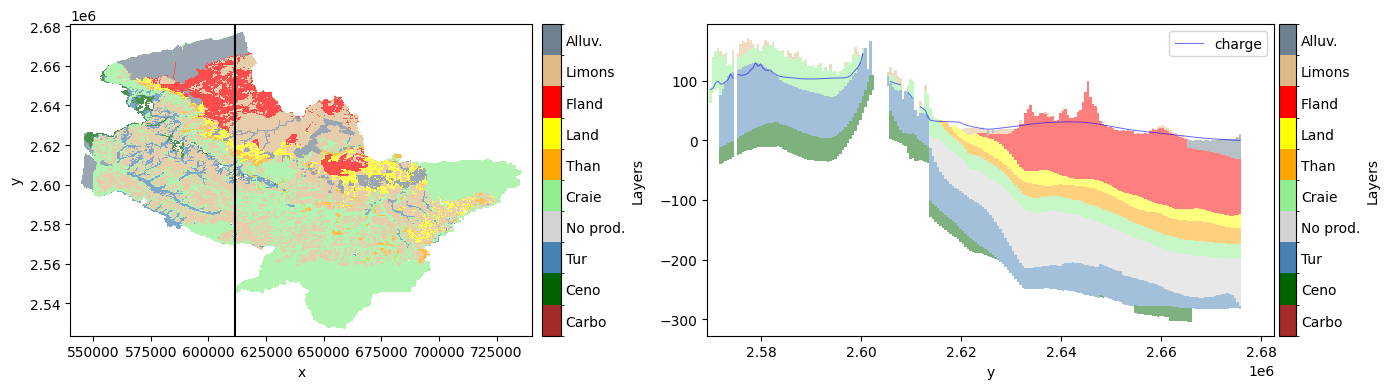

In [6]:

# CREATE AXES
fig, axes = plt.subplots(ncols=2, figsize=(14,4), width_ratios=[0.5, 0.6])

# MAP
ax = axes[0]
gm.plot_outcrop(
    gm.assign_coords(surf, add_lay=False),
    fig=fig, ax=ax, cmap=cmap, norm=norm, labels=labels, cbar_width=4,
    alpha=0.7
)
ax.axvline(x=XC, color='k', label='cross_section')

# CROSS-SECT
ax = axes[1]
gm.plot_cross_section(ds_xs, fig=fig, ax=ax, cmap=cmap, norm=norm, labels=labels)
line.plot(y="charge", x='y', ax=ax, color='blue', linewidth=0.7, alpha=0.6)  # gwl line
ax.set_xlim(2.5692e6)

plt.tight_layout()
plt.show()